In [1]:
from torchvision.models import inception_v3, Inception_V3_Weights
import torch.nn.functional as F
import numpy as np
from scipy import linalg
import torch.nn as nn
import zipfile
from PIL import Image
import io
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Гиперпараметры

In [2]:
latent_dim = 100
channels = 3
image_size = 128
img_dim = channels * image_size * image_size
batch_size = 20
num_epochs = 300

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Модель для FID

In [3]:
class InceptionFeatureExtractor(nn.Module):
    def __init__(self, device):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT
        self.inception = inception_v3(weights=weights)
        self.inception.fc = nn.Identity()
        self.inception.eval()
        self.inception.to(device)

    @torch.no_grad()
    def forward(self, x):
        x = (x + 1) / 2

        x = F.interpolate(
            x, size=(299, 299),
            mode="bilinear",
            align_corners=False
        )

        out = self.inception(x)

        if isinstance(out, tuple):
            out = out[0]

        return out

In [4]:
def compute_statistics(dataloader, model, device, max_batches=50):
    features = []

    for i, imgs in enumerate(dataloader):
        if i >= max_batches:
            break

        imgs = imgs.to(device)
        feats = model(imgs)
        features.append(feats.cpu().numpy())

    features = np.concatenate(features, axis=0)
    mu = np.mean(features, axis=0)
    sigma = np.cov(features, rowvar=False)
    return mu, sigma

Генерация изображений для FID

In [5]:
def generate_fake_images(generator, n_images, latent_dim, device):
    generator.eval()
    imgs = []

    with torch.no_grad():
        for _ in range(n_images // batch_size):
            z = torch.randn(batch_size, latent_dim, device=device)
            fake = generator(z)
            fake = fake.view(-1, 3, image_size, image_size)
            imgs.append(fake)

    return torch.cat(imgs, dim=0)

Подсчёт FID

In [6]:
def calculate_fid(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2

    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

Внимание

In [7]:
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)

        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()

        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        k = self.key(x).view(B, -1, H * W)
        v = self.value(x).view(B, -1, H * W)

        attn = torch.bmm(q, k)
        attn = F.softmax(attn, dim=-1)

        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)

        return self.gamma * out + x

Генератор

In [8]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            # z → 1024×4×4
            nn.ConvTranspose2d(latent_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            # 8×8
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 16×16
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 32×32
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )

        self.attn = SelfAttention(128)

        self.out = nn.Sequential(
            # 64×64
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 128×128
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        x = self.net(z)
        x = self.attn(x)
        img = self.out(x)
        return img
    
    
generator = Generator(latent_dim).to(device)

Дискриминатор

In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.attn = SelfAttention(128)

        self.classifier = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(256, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x, return_features=False):
        feats = self.features(x)
        feats = self.attn(feats)
        out = self.classifier(feats)

        if return_features:
            return out.view(x.size(0), 1), feats

        return out.view(x.size(0), 1)

discriminator = Discriminator().to(device)

Инициализация весов

In [10]:
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)
generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (attn): SelfAttention(
    (query): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
    (key): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
    (value): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (classifier): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): AdaptiveAvgPool2d(output_size=1)
    (4): Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1))
    (5): Sigmoid()
  )
)

Функция потерь и оптимизаторы

In [11]:
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

Обработка данных

In [12]:
class ZipImageDataset(Dataset):
    def __init__(self, zip_path, image_size):
        self.zip_file = zipfile.ZipFile(zip_path)
        self.image_names = [name for name in self.zip_file.namelist() if name.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self): return len(self.image_names)
    def __getitem__(self, idx):
        with self.zip_file.open(self.image_names[idx]) as f:
            img = Image.open(io.BytesIO(f.read())).convert("RGB")
        return self.transform(img)

dataset = ZipImageDataset("data/pizza.zip", image_size=image_size)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

fixed_z = torch.randn(16, latent_dim, device=device)

Генерация изображений

In [13]:
def generate_and_show(generator, fixed_z=None, n_images=16):
    generator.eval()
    with torch.no_grad():
        z = fixed_z[:n_images] if fixed_z is not None else torch.randn(n_images, latent_dim, device=device)
        fake_imgs = generator(z)
        fake_imgs = ((fake_imgs + 1) / 2).view(n_images, 3, 128, 128).permute(0, 2, 3, 1).cpu()
    grid = int(n_images ** 0.5)
    fig, axes = plt.subplots(grid, grid, figsize=(12, 12))
    fig.suptitle('Generated Images (128x128)', fontsize=16)
    for i in range(grid):
        for j in range(grid):
            axes[i, j].imshow(fake_imgs[i*grid + j])
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()
    generator.train()


Загрузка чекпоинта

In [14]:
checkpoint_path = 'gan_checkpoint.pth'
start_epoch = 0
d_losses = []
g_losses = []
fid_history = []
fixed_z = torch.randn(64, latent_dim, device=device)

inception = InceptionFeatureExtractor(device)

real_mu, real_sigma = compute_statistics(
    dataloader, inception, device
)

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    generator.load_state_dict(checkpoint['generator_state'])
    discriminator.load_state_dict(checkpoint['discriminator_state'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state'])
    start_epoch = checkpoint['epoch']
    d_losses = checkpoint['d_losses']
    g_losses = checkpoint['g_losses']
    fid_history = checkpoint.get("fid_history", [])
    fixed_z = checkpoint['fixed_z']
    print(f"Загружен чекпоинт с эпохи {start_epoch}")


Обучение

[Epoch 0/300] [Batch 0] D: 0.7004 G: 9.1369 Real mean: -0.1276 Fake mean: 0.0435
Чекпоинт сохранён: gan_checkpoint.pth


C:\Users\Владимир Савинский\AppData\Local\Temp\ipykernel_22348\844567404.py:4: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
C:\Users\Владимир Савинский\AppData\Local\Temp\ipykernel_22348\844567404.py:4: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)


Epoch 0: FID = 442.45
Epoch 1 samples:


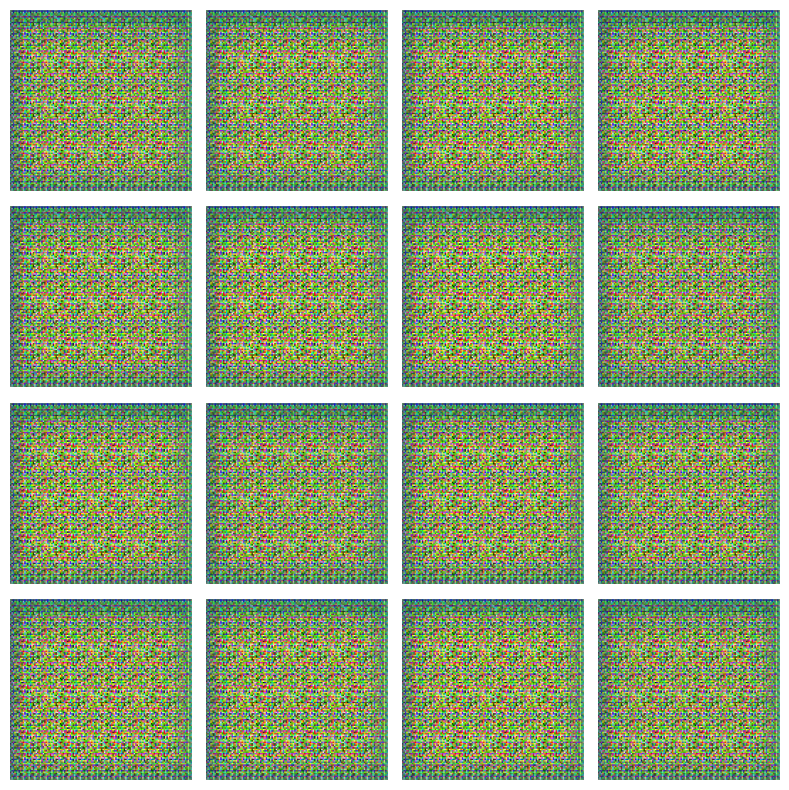

[Epoch 1/300] [Batch 0] D: 0.7331 G: 6.7569 Real mean: -0.1918 Fake mean: -0.0429
[Epoch 2/300] [Batch 0] D: 0.7445 G: 6.6294 Real mean: -0.1663 Fake mean: -0.0483


In [ ]:
for epoch in range(start_epoch, num_epochs):
    for i, real_imgs in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        valid = torch.full((batch_size, 1), 0.9, device=device)
        fake_label = torch.full((batch_size, 1), 0.1, device=device)

        #D
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_imgs = generator(z)

        pred_real, feat_real = discriminator(real_imgs, return_features=True)
        pred_fake, feat_fake = discriminator(fake_imgs.detach(), return_features=True)
        
        real_loss = criterion(pred_real, valid)
        fake_loss = criterion(pred_fake, fake_label)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        #G
        fake_imgs = generator(z)
        bce_g_loss = criterion(discriminator(fake_imgs), valid)

        pred_fake, feat_fake = discriminator(fake_imgs, return_features=True)

        bce_g_loss = criterion(pred_fake, valid)
        fm_loss = F.mse_loss(feat_fake, feat_real.detach())
        
        g_loss = bce_g_loss + 10 * fm_loss

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

        if i % 200 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}] "
                  f"D: {d_loss:.4f} G: {g_loss:.4f} "
                  f"Real mean: {real_imgs.mean():.4f} Fake mean: {fake_imgs.mean():.4f}")

    # Сохранение чекпоинта каждые 10 эпох
    if epoch % 10 == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'generator_state': generator.state_dict(),
            'discriminator_state': discriminator.state_dict(),
            'optimizer_G_state': optimizer_G.state_dict(),
            'optimizer_D_state': optimizer_D.state_dict(),
            'd_losses': d_losses,
            'g_losses': g_losses,
            "fid_history": fid_history,
            'fixed_z': fixed_z
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Чекпоинт сохранён: {checkpoint_path}")

    if epoch % 10 == 0:
        generator.eval()

        fake_imgs = generate_fake_images(
            generator, 1000, latent_dim, device
        )

        fake_mu, fake_sigma = compute_statistics(
            DataLoader(fake_imgs, batch_size=batch_size),
            inception,
            device
        )

        fid = calculate_fid(real_mu, real_sigma, fake_mu, fake_sigma)
        fid_history.append((epoch, fid))

        print(f"Epoch {epoch}: FID = {fid:.2f}")

        generator.train()


    if epoch % 20 == 0:
        print(f"Epoch {epoch+1} samples:")
        generate_and_show(generator, fixed_z)


Результаты обучения

In [ ]:
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    generator.load_state_dict(checkpoint['generator_state'])

    if 'fixed_z' in checkpoint:
        fixed_z = checkpoint['fixed_z']
    if 'd_losses' in checkpoint:
        d_losses = checkpoint['d_losses']
    if 'g_losses' in checkpoint:
        g_losses = checkpoint['g_losses']
    if 'fid_history' in checkpoint:
        fid_history = checkpoint['fid_history']

    print(f"Загружен gan_checkpoint.pth: generator + fixed_z + losses (epoch {checkpoint.get('epoch', 'N/A')})")
else:
    print("gan_checkpoint.pth не найден")

generator.eval()

if len(d_losses) > 0 and len(g_losses) > 0:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(d_losses, label='D loss', alpha=0.8)
    plt.plot(g_losses, label='G loss', alpha=0.8)
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if len(fid_history) > 0:
    epochs, fids = zip(*fid_history)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, fids, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("FID")
    plt.title("FID during GAN training")
    plt.grid(True)
    plt.show()

generate_and_show(generator, fixed_z)